## Thematic Count

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# File Paths
BASE = Path("..").resolve()
OUT = BASE / "out"

CS_COURSE_PATH = OUT / "cs_course_skills.jsonl"
IT_COURSE_PATH = OUT / "it_course_skills.jsonl"

CS_LOCAL_JOBS_PATH = OUT / "local_cs_skills.jsonl"
IT_LOCAL_JOBS_PATH = OUT / "local_it_skills.jsonl"

CS_INTL_JOBS_PATH = OUT / "international_cs_skills.jsonl"
IT_INTL_JOBS_PATH = OUT / "international_it_skills.jsonl"

In [11]:
# Data Loading
cs_courses_df = pd.read_json(CS_COURSE_PATH, lines=True)
it_courses_df = pd.read_json(IT_COURSE_PATH, lines=True)

cs_local_jobs_df = pd.read_json(CS_LOCAL_JOBS_PATH, lines=True)
it_local_jobs_df = pd.read_json(IT_LOCAL_JOBS_PATH, lines=True)

cs_intl_jobs_df = pd.read_json(CS_INTL_JOBS_PATH, lines=True)
it_intl_jobs_df = pd.read_json(IT_INTL_JOBS_PATH, lines=True)

In [12]:
# Count records in each dataset
cs_course_count = cs_courses_df.shape[0]
it_course_count = it_courses_df.shape[0]

cs_local_job_count = cs_local_jobs_df.shape[0]
it_local_job_count = it_local_jobs_df.shape[0]

cs_intl_job_count = cs_intl_jobs_df.shape[0]
it_intl_job_count = it_intl_jobs_df.shape[0]

# Build pandas DataFrames for summary/consistency
courses_counts_df = pd.DataFrame(
    {
        "Thematic Area": ["Computer Science", "Information Technology"],
        "Records": [cs_course_count, it_course_count],
    }
)

local_jobs_counts_df = pd.DataFrame(
    {
        "Thematic Area": ["Computer Science", "Information Technology"],
        "Records": [cs_local_job_count, it_local_job_count],
    }
)

international_jobs_counts_df = pd.DataFrame(
    {
        "Thematic Area": ["Computer Science", "Information Technology"],
        "Records": [cs_intl_job_count, it_intl_job_count],
    }
)

summary_df = (
    courses_counts_df.rename(columns={"Records": "Course Records"})
    .merge(
        local_jobs_counts_df.rename(columns={"Records": "Local Job Records"}),
        how="outer",
        on="Thematic Area",
    )
    .merge(
        international_jobs_counts_df.rename(columns={"Records": "International Job Records"}),
        how="outer",
        on="Thematic Area",
    )
)

summary_df

,Thematic Area,Course Records,Local Job Records,International Job Records
0,Computer Science,35,13,1315
1,Information Technology,29,13,1354


---
# Course Outline Comparison
---

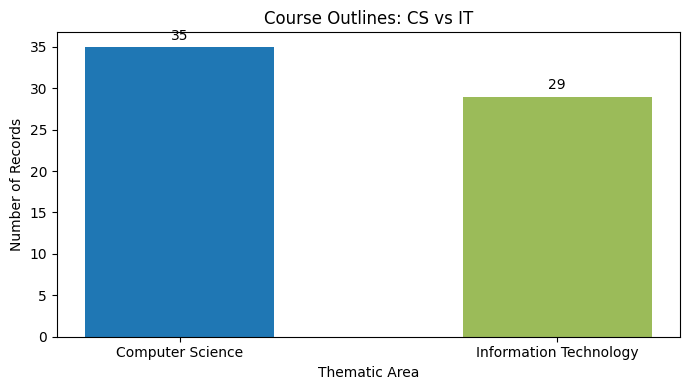

In [13]:
# Course Outlines Comparison
domains = courses_counts_df["Thematic Area"].tolist()
records = courses_counts_df["Records"].tolist()

plt.figure(figsize=(7, 4))
bars = plt.bar(domains, records, color=["#1f77b4", "#9BBB59"], width=0.5)
plt.title("Course Outlines: CS vs IT")
plt.xlabel("Thematic Area")
plt.ylabel("Number of Records")
# plt.xticks(rotation=90)
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

---
# Local Job Comparison
---

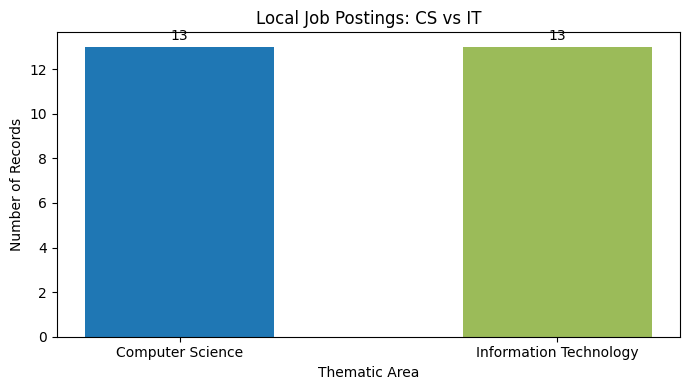

In [14]:
# Local Jobs Comparison 
domains = local_jobs_counts_df["Thematic Area"].tolist()
records = local_jobs_counts_df["Records"].tolist()

plt.figure(figsize=(7, 4))
bars = plt.bar(domains, records, color=["#1f77b4", "#9BBB59"], width=0.5)
plt.title("Local Job Postings: CS vs IT")
plt.xlabel("Thematic Area")
plt.ylabel("Number of Records")
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

---
# International Job Comparison
---

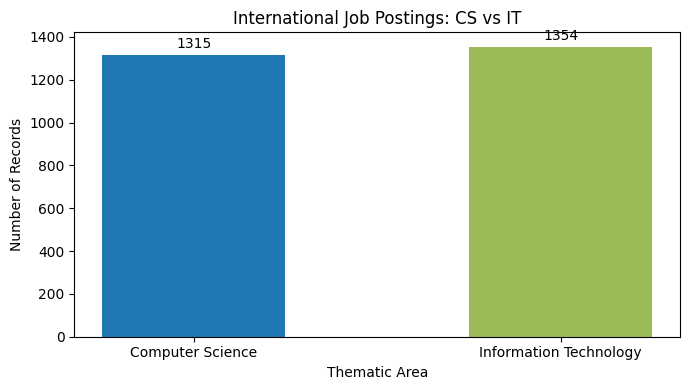

In [15]:
# International Jobs Comparison
domains = international_jobs_counts_df["Thematic Area"].tolist()
records = international_jobs_counts_df["Records"].tolist()

plt.figure(figsize=(7, 4))
bars = plt.bar(domains, records, color=["#1f77b4", "#9BBB59"], width=0.5)
plt.title("International Job Postings: CS vs IT")
plt.xlabel("Thematic Area")
plt.ylabel("Number of Records")
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()